### Inicialización

Trabajas en una empresa emergente que vende productos alimenticios. Debes investigar el comportamiento del usuario para la aplicación de la empresa.

Primero, estudia el embudo de ventas. Descubre cómo los usuarios llegan a la etapa de compra. ¿Cuántos usuarios realmente llegan a esta etapa? ¿Cuántos se atascan en etapas anteriores? ¿Qué etapas en particular?

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

# Leer el archivo CSV
logs = pd.read_csv('logs_exp_us.csv', sep='\t')

# Mostrar las primeras filas
print(logs.head())

# Información general del DataFrame
print(logs.info())

# Ver columnas disponibles
print(logs.columns)

# Comprobar valores faltantes
print(logs.isna().sum())

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None
Index(['EventName', 'DeviceIDHash', 'EventTimestamp', 'ExpId'], dtype='object')
EventName         0
DeviceIDHash      0
EventTimestamp    0

Vemos que las columnas estan en mayúsculas y no están en formato snake case, vamos a modificarlo para que sea más legible.

In [2]:
# Renombrar las columnas a formato snake_case
logs.columns = logs.columns.str.lower().str.replace(' ', '_')

logs = logs.rename(columns={
    'eventname': 'event_name',
    'deviceidhash': 'device_id',
    'eventtimestamp': 'event_timestamp',
    'expid': 'exp_id'
})

# Verificamos los nuevos nombres
print(logs.columns)

Index(['event_name', 'device_id', 'event_timestamp', 'exp_id'], dtype='object')


In [3]:
# Convertir el timestamp a fecha y hora legible ---
logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')
print(logs[['event_timestamp', 'event_datetime']].head())


   event_timestamp      event_datetime
0       1564029816 2019-07-25 04:43:36
1       1564053102 2019-07-25 11:11:42
2       1564054127 2019-07-25 11:28:47
3       1564054127 2019-07-25 11:28:47
4       1564055322 2019-07-25 11:48:42


2019-07-25 04:43:36 2019-08-07 21:15:17


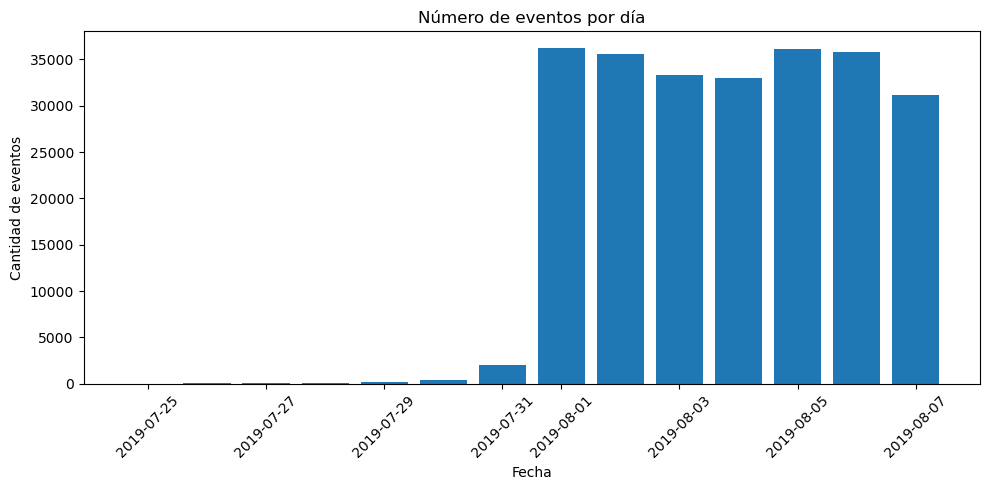

In [4]:
# Comprobar rango de fechas
print(logs['event_datetime'].min(), logs['event_datetime'].max())
# Agrupar eventos por día
logs['date'] = logs['event_datetime'].dt.date
events_per_day = logs.groupby('date').size()

# Graficar histograma de eventos por día
plt.figure(figsize=(10,5))
plt.bar(events_per_day.index, events_per_day.values)
plt.title('Número de eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Actividad casi nula entre el 25 y el 30 de julio, lo que indica que el experimento aún no había comenzado o estaba en fase de pruebas internas.

A partir del 31 de julio, el número de eventos se incrementa drásticamente, superando los 30 000 eventos diarios.

La actividad se mantiene constante del 1 al 6 de agosto, lo cual sugiere un experimento estable.

El 7 de agosto hay una leve caída, probablemente porque el registro terminó ese día antes de completarse las 24 h.

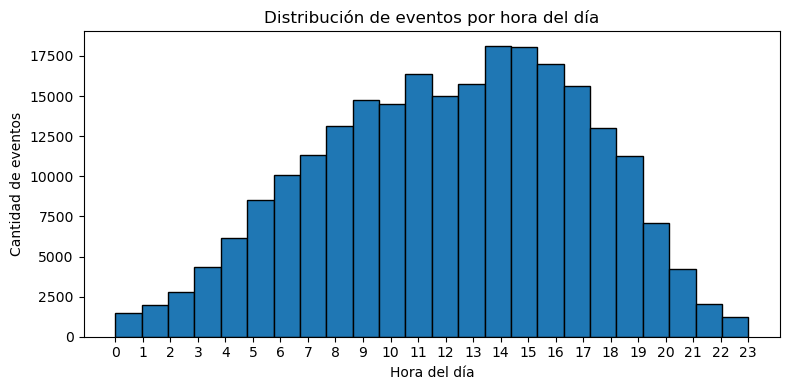

In [10]:
# Extraer la hora del evento
logs['hour'] = logs['event_datetime'].dt.hour

# Graficar histograma de eventos por hora del día
plt.figure(figsize=(8,4))
plt.hist(logs['hour'], bins=24, edgecolor='black')
plt.title('Distribución de eventos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de eventos')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

La actividad comienza a aumentar alrededor de las 5–6 a.m.
(primeros usuarios que abren la app al comenzar el día).

Desde las 7 a.m. hasta las 3 p.m. se observa un crecimiento sostenido,
alcanzando el pico máximo alrededor de las 2 p.m. (14 h)
con casi 18 000 eventos por hora.

Después del mediodía, la actividad permanece alta hasta las 16–17 h,
y luego comienza a descender gradualmente hasta llegar a niveles mínimos por la noche (22–23 h).

In [5]:
# Contar usuarios únicos
print("Usuarios únicos:", logs['device_id'].nunique())

# Contar eventos únicos
print("Eventos únicos:", logs['event_name'].unique())

# Contar cuántas veces ocurre cada tipo de evento
event_counts = logs['event_name'].value_counts()
print(event_counts)

Usuarios únicos: 7551
Eventos únicos: ['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']
event_name
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64


1.	Todos los usuarios pasan por MainScreenAppear, como punto de inicio.
2.	Muchos luego ven ofertas (OffersScreenAppear), lo que indica curiosidad o interés inicial.
3.	Una buena cantidad llega al carrito (CartScreenAppear), pero no todos completan la compra.
4.	Finalmente, 34 313 eventos de compra muestran que una parte significativa sí convierte, pero todavía hay pérdida entre explorar / añadir y pagar.
5.	El evento Tutorial tiene muy pocos registros, probablemente solo se muestra una vez por usuario nuevo.

 Los usuarios siguen, en promedio, una ruta como:
 
 MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful

### ¿Cuántos usuarios realmente llegan a esta etapa? ¿Cuántos se atascan en etapas anteriores? ¿Qué etapas en particular?

In [6]:
# Contar usuarios únicos por cada etapa del embudo
stages = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

users_by_stage = (
    logs.query('event_name in @stages')
    .groupby('event_name')['device_id']
    .nunique()
    .reindex(stages)
    .reset_index()
)

users_by_stage.columns = ['event_name', 'unique_users']
print(users_by_stage)

# Calcular tasas de conversión entre etapas
users_by_stage['conversion_from_previous'] = (
    users_by_stage['unique_users'] / users_by_stage['unique_users'].iloc[0]
)

print("\nUsuarios por etapa del embudo:")
print(users_by_stage)

                event_name  unique_users
0         MainScreenAppear          7439
1       OffersScreenAppear          4613
2         CartScreenAppear          3749
3  PaymentScreenSuccessful          3547

Usuarios por etapa del embudo:
                event_name  unique_users  conversion_from_previous
0         MainScreenAppear          7439                  1.000000
1       OffersScreenAppear          4613                  0.620110
2         CartScreenAppear          3749                  0.503966
3  PaymentScreenSuccessful          3547                  0.476811


### ¿Cuántos usuarios realmente llegan a la etapa de compra?
3547 usuarios realizaron al menos un evento PaymentScreenSuccessful.

Eso representa el 47.7 % de todos los que abrieron la app (MainScreenAppear).

### ¿Cuántos usuarios se atascan en etapas anteriores?

Aqui hacemos la resta dependiendo de las etapas anteriores, por ejemplo

El 100% de usuarios únicos fué un total de 7439 que es el MainScreenAppear.

El OffersScreenAppear fué de 4613 un 62%, entonces 2826 usuarios no pasaron a ver ofertas.

CartScreenAppear fué de 3749, 81% desde ofertas lo cual 864 usuarios no abrieron el carrito.

PaymentScreenSuccessful fué de 3547, 95% desde la etapa del carrito lo cual 202 usuarios abandonaron antes del pago.

### ¿En qué etapas se atascan más?

La mayor pérdida ocurre entre “MainScreenAppear” y “OffersScreenAppear”
Un 38 % de los usuarios abandona antes incluso de ver las ofertas o interactuar con la app.
Esto podría indicar que:

•	La pantalla principal no incentiva lo suficiente a explorar

•	Hay problemas de usabilidad o carga inicial.











### Luego, observa los resultados de un test A/A/B (sigue leyendo para obtener más información sobre los test A/A/B). Al equipo de diseño le gustaría cambiar las fuentes de toda la aplicación, pero la gerencia teme que los usuarios piensen que el nuevo diseño es intimidante. Por ello, deciden tomar una decisión basada en los resultados de un test A/A/B.

In [7]:
# Ver cuántos usuarios hay por experimento
experiment_counts = logs.groupby('exp_id')['device_id'].nunique().reset_index()
experiment_counts.columns = ['exp_id', 'unique_users']
print(experiment_counts)

   exp_id  unique_users
0     246          2489
1     247          2520
2     248          2542


Los tamaños son muy similares, lo cual es excelente:

Esto garantiza que la asignación de usuarios fue equilibrada y aleatoria, condición clave para un test A/A/B válido.

In [8]:
# Vamos a calcular compradores por experimento 
buyers_by_exp = (
    logs.query("event_name == 'PaymentScreenSuccessful'")
    .groupby('exp_id')['device_id']
    .nunique()
    .reset_index(name='buyers')
)

# Usuarios totales por experimento 
users_by_exp = logs.groupby('exp_id')['device_id'].nunique().reset_index(name='total_users')

# Combinar y calcular la tasa de conversión
conversion = pd.merge(users_by_exp, buyers_by_exp, on='exp_id', how='left')
conversion['conversion_rate'] = conversion['buyers'] / conversion['total_users']

print(conversion)

   exp_id  total_users  buyers  conversion_rate
0     246         2489    1202         0.482925
1     247         2520    1160         0.460317
2     248         2542    1185         0.466168


Grupos A₁ y A₂ (A/A test):
• Sus tasas son muy similares (48.3 % vs 46.0 %)

• Lo que indica que no hay sesgo significativo entre los grupos de control.

• El experimento es válido y equilibrado.

Grupo B (nuevo diseño):
• Conversión: 46.6 %, muy cercana a la de los grupos A.

• A simple vista, no parece haber un cambio grande por la nueva fuente.

In [9]:
# Prueba de hipótesis (A/A/B)

# Datos
buyers = np.array([1202, 1160, 1185])
users = np.array([2489, 2520, 2542])

# --- 1) Comparar A1 vs A2 ---
p1, p2 = buyers[0]/users[0], buyers[1]/users[1]
p_combined = (buyers[0] + buyers[1]) / (users[0] + users[1])
z_stat = (p1 - p2) / np.sqrt(p_combined*(1 - p_combined)*(1/users[0] + 1/users[1]))
p_value = 2 * (1 - st.norm.cdf(abs(z_stat)))

print("A1 vs A2 → z = %.3f, p = %.4f" % (z_stat, p_value))

# --- 2) Comparar A (combinado) vs B ---
buyers_a = buyers[0] + buyers[1]
users_a = users[0] + users[1]
buyers_b = buyers[2]
users_b = users[2]

p_a, p_b = buyers_a/users_a, buyers_b/users_b
p_combined2 = (buyers_a + buyers_b) / (users_a + users_b)
z_stat2 = (p_a - p_b) / np.sqrt(p_combined2*(1 - p_combined2)*(1/users_a + 1/users_b))
p_value2 = 2 * (1 - st.norm.cdf(abs(z_stat2)))

print("A (combined) vs B → z = %.3f, p = %.4f" % (z_stat2, p_value2))

A1 vs A2 → z = 1.603, p = 0.1090
A (combined) vs B → z = 0.443, p = 0.6578


A₁ vs A₂ (control vs control)

p = 0.109 > 0.05

No hay diferencia significativa entre los dos grupos de control.

Esto significa que los usuarios asignados aleatoriamente a cada grupo se comportaron igual.

El experimento es confiable, no hubo sesgo en la división.

A (combinado) vs B (nuevo diseño)

p = 0.6578 > 0.05

No hay evidencia estadística de diferencia entre el diseño actual y el nuevo con fuentes distintas.

La tasa de conversión de B (46.6 %) es ligeramente menor que la de A (47.1 %),
pero la diferencia no es lo suficientemente grande para considerarse real y no fruto del azar.

### ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.

Total aproximado de pruebas de hipótesis:

1 (A/A) + 1 (A vs B) + 15 = 17 pruebas

Con α = 0.05 y 17 pruebas, el riesgo acumulado de obtener al menos un falso positivo es:

1 - (1 - 0.05)^{17} ≈ 0.58

Esto significa que hay un 58 % de probabilidad de tener al menos un falso positivo si no se corrige el nivel de significancia.

Si en lugar de 0.05 usas α = 0.1,
significa que uno de cada 10 resultados podría ser falso → un riesgo más alto.

Con α = 0.1 y 17 pruebas:

1 - (1 - 0.1)^{17} ≈ 0.82

82 % de probabilidad de tener al menos un falso positivo.
No es recomendable en experimentos A/B con múltiples comparaciones.

Ninguna de las comparaciones tiene un p-valor menor a 0.05 ni mucho menos a 0.003,
por lo que el resultado sigue siendo el mismo.

No hay diferencias significativas entre los grupos, y la división fue correcta.